## 1.Import Necessary Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

## 2.Import Datasets

In [13]:
college_data=pd.read_csv("college_list.csv")
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


## 3.Data Undertsanding

In [14]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


In [15]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [17]:
college_data.dtypes

College_Name                 str
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object

In [18]:
college_data["College_Name"].unique()

<StringArray>
[             'Indian Institute of Technology Madras - Campus 1',
            'National Institute of Technology Trichy - Campus 1',
                            'Anna University Chennai - Campus 1',
                          'PSG College of Technology - Campus 1',
                 'Coimbatore Institute of Technology - Campus 1',
        'Government College of Technology Coimbatore - Campus 1',
                         'SSN College of Engineering - Campus 1',
            'SRM Institute of Science and Technology - Campus 1',
                                        'VIT Vellore - Campus 1',
                                  'SASTRA University - Campus 1',
 ...
                    'Sri Sairam Engineering College - Campus 17',
                      'Velammal Engineering College - Campus 17',
                   'Rajalakshmi Engineering College - Campus 17',
                 'St Josephs College of Engineering - Campus 17',
                  'Kumaraguru College of Technology - Cam

## 4.Data Preperation

#### 4.1 Delete Unnecessary column

In [21]:
x=college_data.drop("College_Name",axis=1)
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


#### 4.2 Data transformation

In [27]:
from sklearn.preprocessing import StandardScaler

std_scaler=StandardScaler()
scaled_x=std_scaler.fit_transform(x)
scaled_x=pd.DataFrame(scaled_x)
scaled_x

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


## 5.Model Building

### 5.1 Let's check Dendogram

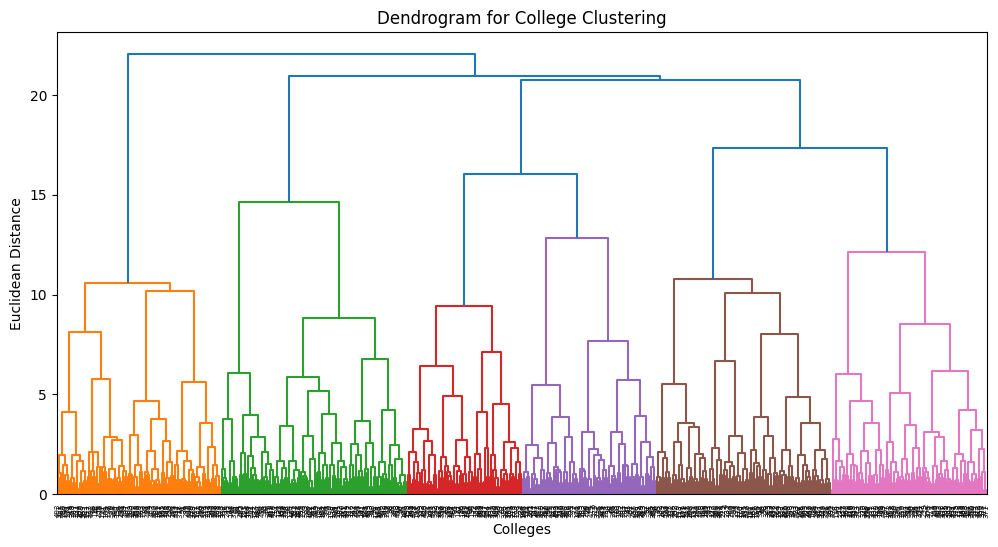

In [28]:
plt.figure(figsize=(12,6))
dendogram=sch.dendrogram(sch.linkage(scaled_x,method='ward'))
plt.title("Dendrogram for College Clustering")
plt.xlabel("Colleges")
plt.ylabel("Euclidean Distance")
plt.show()

### Step 2: Apply Agglomerative clustering(Based on Dendogram choose 3 clusters)

In [29]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",3
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [32]:
clusters=hc.fit_predict(scaled_x)
clusters

array([2, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 0, 2, 0, 1, 1, 0, 2,
       2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 2,
       0, 2, 1, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0,
       2, 0, 0, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0,
       1, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0,

## Clustering is done.Let's put back to the original Dataset for further Data Mining Operation

## ======================================================

## Level 2: Attach clusters to Dataset

In [33]:
college_data["college_level"]=clusters

In [34]:
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


## 2.Data Undertanding - Analyze Clusters

In [35]:
college_data[college_data["college_level"]==0]

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
5,Government College of Technology Coimbatore - ...,28,226582,45,9.32,4,0
...,...,...,...,...,...,...,...
494,Kumaraguru College of Technology - Campus 17,11,34324,73,11.40,3,0
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [38]:
college_data.groupby(by="college_level").agg(['mean'])

TypeError: dtype 'str' does not support operation 'mean'

## We had categorical column so we are not able to take mean for the complete Datasets

In [39]:
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [41]:
x["college_level"]=clusters
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0
496,12,39111,76,3.62,7,0
497,16,199182,64,3.88,3,1
498,10,46389,77,9.31,6,0


In [42]:
x.groupby(by="college_level").agg(["mean"])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
college_level,,,,,
0,20.407051,121853.471154,67.278846,6.954583,6.509615
1,17.159091,156795.136364,85.568182,5.565682,3.965909
2,11.650000,175656.000000,59.790000,8.362500,6.080000


In [43]:
x.groupby(by="college_level").agg(["min","max"])

Student_Faculty_Ratio     Annual_Fees_INR          \
                                min max             min     max   
college_level                                                     
0                                 8  29           30404  249536   
1                                 8  29           39337  248803   
2                                 8  20           49065  249930   

              Placement_Percentage     Average_Package_LPA         \
                               min max                 min    max   
college_level                                                       
0                               40  99                2.00  11.99   
1                               64  99                2.09  11.96   
2                               40  99                2.01  11.91   

              Infrastructure_Score      
                               min max  
college_level                           
0                                3   9  
1                                3   9  
2                                3   9

In [44]:
cluster_names = {1: "Best Colleges",
                 2: "Mid-Level Colleges",
                 0: "Emerging / Lower-Level Colleges"}


x["category"]=x["college_level"].map(cluster_names)

In [45]:
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level,category
0,14,113042,59,9.20,8,2,Mid-Level Colleges
1,27,115999,67,3.07,7,0,Emerging / Lower-Level Colleges
2,22,47955,50,3.40,9,0,Emerging / Lower-Level Colleges
3,18,67841,43,4.64,8,0,Emerging / Lower-Level Colleges
4,15,100640,54,4.66,9,0,Emerging / Lower-Level Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Emerging / Lower-Level Colleges
496,12,39111,76,3.62,7,0,Emerging / Lower-Level Colleges
497,16,199182,64,3.88,3,1,Best Colleges
498,10,46389,77,9.31,6,0,Emerging / Lower-Level Colleges


## ======================================================

## Level 3: Now it's time to transition to supervised learning

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

input_data=x.drop(["college_level","category"],axis=1)
output_data=x["college_level"]

# Split
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.20, random_state=42,stratify = output_data)

# Train Model
model = RandomForestClassifier()
model.fit(x_train, y_train)

# Accuracy
print("Accuracy:", model.score(x_test, y_test))

Accuracy: 0.92


## Take the model out to add in the backend

In [51]:
import pickle
pickle.dump(model,open("college_category_model.pkl","wb"))

## THE End